In [1]:
import os
import cv2
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# =========================
# Paths
# =========================
base = "DemoSet"
img_dir = os.path.join(base, "DemoImage")
target_dir = os.path.join(base, "DemoTargetIfNecessary")

# =========================
# Collect samples
# =========================
X = []
y = []

print("Starting script...")
files = sorted(os.listdir(img_dir))

for file in files:
    if "post_disaster" not in file:
        continue

    post_path = os.path.join(img_dir, file)
    pre_path = post_path.replace("post_disaster", "pre_disaster")
    target_path = os.path.join(target_dir, file.replace(".png", "_target.png"))

    if not os.path.exists(pre_path) or not os.path.exists(target_path):
        continue

    # -------------------------
    # Load images
    # -------------------------
    pre = cv2.imread(pre_path)
    post = cv2.imread(post_path)
    target = cv2.imread(target_path, 0)  # grayscale mask

    if pre is None or post is None or target is None:
        continue

    # -------------------------
    # Resize for speed
    # -------------------------
    pre = cv2.resize(pre, (128, 128))
    post = cv2.resize(post, (128, 128))
    target = cv2.resize(target, (128, 128), interpolation=cv2.INTER_NEAREST)

    # =========================
    # Create NEW landing labels from xBD target
    # 0 = safe
    # 1 = caution
    # 2 = unsafe
    # =========================
    true_obstacle = (target > 0).astype(np.uint8)

    kernel = np.ones((7, 7), np.uint8)
    dilated_true = cv2.dilate(true_obstacle, kernel, iterations=1)

    landing_mask = np.zeros_like(target, dtype=np.uint8)
    landing_mask[dilated_true == 1] = 1
    landing_mask[true_obstacle == 1] = 2

    # =========================
    # Build SPATIAL FEATURES WITHOUT LEAKAGE
    # =========================

    # 1. Basic RGB change
    pre_f = pre.astype(np.float32)
    post_f = post.astype(np.float32)
    diff = post_f - pre_f

    # 2. Local mean colour from post image
    post_mean = cv2.blur(post_f, (5, 5))

    # 3. Local variance / texture from post grayscale
    post_gray = cv2.cvtColor(post, cv2.COLOR_BGR2GRAY).astype(np.float32)
    post_gray_mean = cv2.blur(post_gray, (5, 5))
    post_gray_sq_mean = cv2.blur(post_gray ** 2, (5, 5))
    post_var = post_gray_sq_mean - (post_gray_mean ** 2)
    post_var = post_var / (post_var.max() + 1e-8)

    # 4. Approximate obstacle map from image only (NO target usage)
    # Bright, sharp regions are a crude proxy for structures/obstacles
    edges = cv2.Canny(post, 100, 200)
    edges = (edges > 0).astype(np.uint8)

    # Dilate edges a bit to make them more spatially meaningful
    approx_obstacle = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)

    # Distance to estimated obstacle (from image, not from ground truth)
    free_space = 1 - approx_obstacle
    distance = cv2.distanceTransform(free_space, cv2.DIST_L2, 5)
    distance = distance / (distance.max() + 1e-8)

    # Optional: local edge density
    edge_density = cv2.blur(edges.astype(np.float32), (5, 5))

    # =========================
    # Combine features
    # =========================
    features = np.concatenate([
        pre_f.reshape(-1, 3),              # pre RGB
        post_f.reshape(-1, 3),             # post RGB
        diff.reshape(-1, 3),               # RGB change
        post_mean.reshape(-1, 3),          # local mean RGB
        post_var.reshape(-1, 1),           # local texture
        distance.reshape(-1, 1),           # distance to estimated obstacle
        edge_density.reshape(-1, 1)        # local edge density
    ], axis=1)

    labels = landing_mask.flatten()

    X.append(features)
    y.append(labels)

# =========================
# Combine all images
# =========================
X = np.vstack(X)
y = np.hstack(y)

print("Dataset shape:", X.shape, y.shape)
print("Classes in new landing labels:", np.unique(y))

# =========================
# Train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# Train Random Forest
# =========================
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

# =========================
# Predict
# =========================
y_pred = rf.predict(X_test)

# =========================
# Evaluation
# =========================
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Starting script...
Dataset shape: (1015808, 15) (1015808,)
Classes in new landing labels: [0 1 2]
Confusion Matrix:
[[135213   5742    968]
 [ 13669  19096   4600]
 [  3777   6429  13668]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92    141923
           1       0.61      0.51      0.56     37365
           2       0.71      0.57      0.63     23874

    accuracy                           0.83    203162
   macro avg       0.74      0.68      0.70    203162
weighted avg       0.81      0.83      0.82    203162




Available demo images:
0: hurricane-florence_00000117_post_disaster.png
1: hurricane-florence_00000119_post_disaster.png
2: hurricane-florence_00000125_post_disaster.png
3: hurricane-florence_00000127_post_disaster.png
4: hurricane-florence_00000128_post_disaster.png
5: hurricane-florence_00000129_post_disaster.png
6: hurricane-florence_00000131_post_disaster.png
7: hurricane-florence_00000133_post_disaster.png
8: hurricane-harvey_00000063_post_disaster.png
9: hurricane-harvey_00000064_post_disaster.png
10: hurricane-harvey_00000068_post_disaster.png
11: hurricane-harvey_00000078_post_disaster.png
12: hurricane-harvey_00000093_post_disaster.png
13: hurricane-harvey_00000096_post_disaster.png
14: hurricane-harvey_00000282_post_disaster.png
15: hurricane-harvey_00000290_post_disaster.png
16: hurricane-harvey_00000293_post_disaster.png
17: hurricane-harvey_00000295_post_disaster.png
18: hurricane-harvey_00000296_post_disaster.png
19: hurricane-harvey_00000306_post_disaster.png
20: hurric

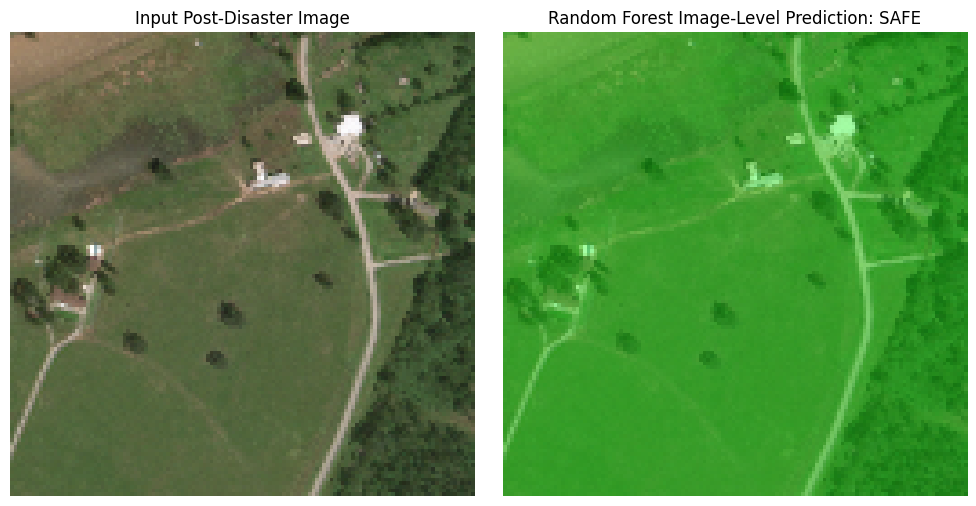

In [ ]:
# =========================
# Visualisation of image-level Random Forest prediction
# =========================

available_files = []

for file in sorted(os.listdir(img_dir)):
    if "post_disaster" not in file:
        continue

    post_path = os.path.join(img_dir, file)
    pre_path = post_path.replace("post_disaster", "pre_disaster")

    if os.path.exists(pre_path):
        available_files.append(file)

print("\nAvailable demo images:")
for i, file in enumerate(available_files):
    print(f"{i}: {file}")

# CHANGE THIS NUMBER to choose the image you want
choice_index = 10

demo_file = available_files[choice_index]
print("\nChosen demo image:", demo_file)

post_path = os.path.join(img_dir, demo_file)
pre_path = post_path.replace("post_disaster", "pre_disaster")

# -------------------------
# Load chosen image
# -------------------------
pre = cv2.imread(pre_path)
post = cv2.imread(post_path)

if pre is None or post is None:
    raise ValueError("Could not load selected pre/post image.")

pre = cv2.resize(pre, (128, 128))
post = cv2.resize(post, (128, 128))

# Convert post image to RGB for matplotlib
demo_rgb = cv2.cvtColor(post, cv2.COLOR_BGR2RGB)

# -------------------------
# Build the SAME features used for training
# -------------------------
pre_f = pre.astype(np.float32)
post_f = post.astype(np.float32)
diff = post_f - pre_f

post_mean = cv2.blur(post_f, (5, 5))

post_gray = cv2.cvtColor(post, cv2.COLOR_BGR2GRAY).astype(np.float32)
post_gray_mean = cv2.blur(post_gray, (5, 5))
post_gray_sq_mean = cv2.blur(post_gray ** 2, (5, 5))
post_var = post_gray_sq_mean - (post_gray_mean ** 2)
post_var = post_var / (post_var.max() + 1e-8)

edges = cv2.Canny(post, 100, 200)
edges = (edges > 0).astype(np.uint8)

approx_obstacle = cv2.dilate(edges, np.ones((3, 3), np.uint8), iterations=1)

free_space = 1 - approx_obstacle
distance = cv2.distanceTransform(free_space, cv2.DIST_L2, 5)
distance = distance / (distance.max() + 1e-8)

edge_density = cv2.blur(edges.astype(np.float32), (5, 5))

demo_features = np.concatenate([
    pre_f.reshape(-1, 3),
    post_f.reshape(-1, 3),
    diff.reshape(-1, 3),
    post_mean.reshape(-1, 3),
    post_var.reshape(-1, 1),
    distance.reshape(-1, 1),
    edge_density.reshape(-1, 1)
], axis=1)

# -------------------------
# Predict every pixel first
# -------------------------
pixel_preds = rf.predict(demo_features)

counts = np.bincount(pixel_preds, minlength=3)
percentages = counts / counts.sum() * 100

safe_pct = percentages[0]
caution_pct = percentages[1]
unsafe_pct = percentages[2]

print(f"Safe pixels: {safe_pct:.2f}%")
print(f"Caution pixels: {caution_pct:.2f}%")
print(f"Unsafe pixels: {unsafe_pct:.2f}%")

# -------------------------
# Convert pixel predictions into ONE image-level label
# -------------------------
if unsafe_pct >= 5:
    image_label = 2
elif caution_pct + unsafe_pct >= 15:
    image_label = 1
else:
    image_label = 0

# -------------------------
# Create green/red overlay on actual image
# -------------------------
if image_label == 0:
    final_label = "SAFE"
    overlay_colour = np.array([0, 255, 0], dtype=np.uint8)   # green
else:
    final_label = "UNSAFE"
    overlay_colour = np.array([255, 0, 0], dtype=np.uint8)   # red

colour_layer = np.zeros_like(demo_rgb, dtype=np.uint8)
colour_layer[:, :] = overlay_colour

alpha = 0.35
overlayed_image = cv2.addWeighted(demo_rgb, 1 - alpha, colour_layer, alpha, 0)

# -------------------------
# Show original and overlay result
# -------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(demo_rgb)
plt.title("Input Post-Disaster Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlayed_image)
plt.title(f"Random Forest Image-Level Prediction: {final_label}")
plt.axis("off")

plt.tight_layout()
plt.savefig("rf_overlay_image_level_classification.png", dpi=300, bbox_inches="tight")
plt.show()